# Time series forecasting 

## Importación de librerías y paquetes y definición de constantes

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Descomposición
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
# Modelado
from pmdarima import auto_arima
# To save models
import json
import pickle
# from tqdm import tqdm
import warnings


In [2]:
def warn(*args, **kwargs):
    pass

warnings.warn = warn

## Recopilación de datos

In [3]:
df = pd.read_csv("../data/raw/sales.csv")
df.head()

,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633


## Análisis descriptivo 

In [4]:
df

,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633
...,...,...
361,2023-08-30 17:10:08.079328,989.600354
362,2023-08-31 17:10:08.079328,994.987326
363,2023-09-01 17:10:08.079328,995.814415
364,2023-09-02 17:10:08.079328,997.350214


In [5]:
df.shape

(366, 2)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    366 non-null    object 
 1   sales   366 non-null    float64
dtypes: float64(1), object(1)
memory usage: 5.8+ KB


In [7]:
df.nunique()

date     366
sales    366
dtype: int64

## Limpieza de datos

### Eliminar duplicados:

In [8]:
df.duplicated().sum()

0

### No hay duplicados pero nos aseguramos de borrarlos

In [9]:
if df.duplicated().sum():
    df = df.drop_duplicates(keep='first')
print(df.shape)
df.head()

(366, 2)


,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633


In [10]:
df.duplicated().sum()

0

### Valores nulos o faltantes:

In [11]:
df.isnull().sum().sort_values(ascending=False) / len(df)

date     0.0
sales    0.0
dtype: float64

#### No hay valores nulos

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
sales,366.0,524.963968,275.089698,53.803211,290.186822,520.699468,763.289263,1000.482785


### Convertir la fecha a datatime

In [13]:
df["date"] = pd.to_datetime(df["date"]).dt.normalize()
df = df.set_index('date')

In [14]:
df

,sales
date,
2022-09-03,55.292157
2022-09-04,53.803211
2022-09-05,58.141693
2022-09-06,64.530899
2022-09-07,66.013633
...,...
2023-08-30,989.600354
2023-08-31,994.987326
2023-09-01,995.814415


## Análisis de variables:

### Visualizamos la evolución de la variable en el tiempo

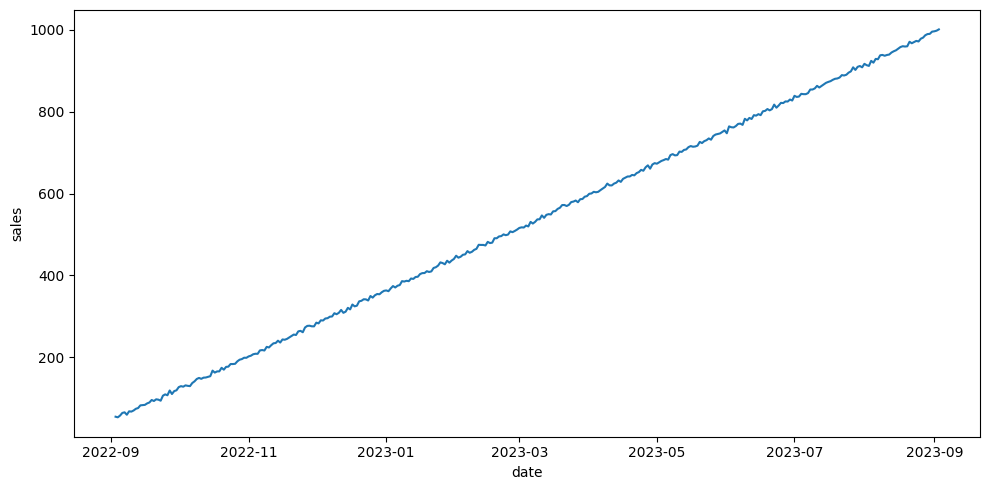

In [15]:
fig, axis = plt.subplots(figsize = (10, 5))
sns.lineplot(data = df['sales'])
plt.tight_layout()
plt.show()

In [16]:
decomposition = seasonal_decompose(df['sales'], period = 12)
decomposition

### Tendencia

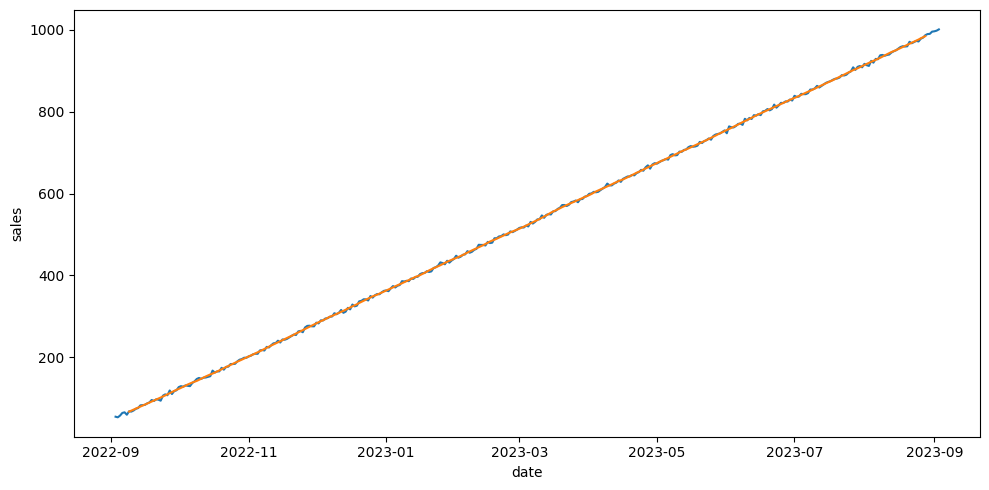

In [17]:
trend = decomposition.trend
fig, axis = plt.subplots(figsize = (10, 5))
sns.lineplot(data = df['sales'])
sns.lineplot(data = trend)
plt.tight_layout()
plt.show()

### Estacionalidad

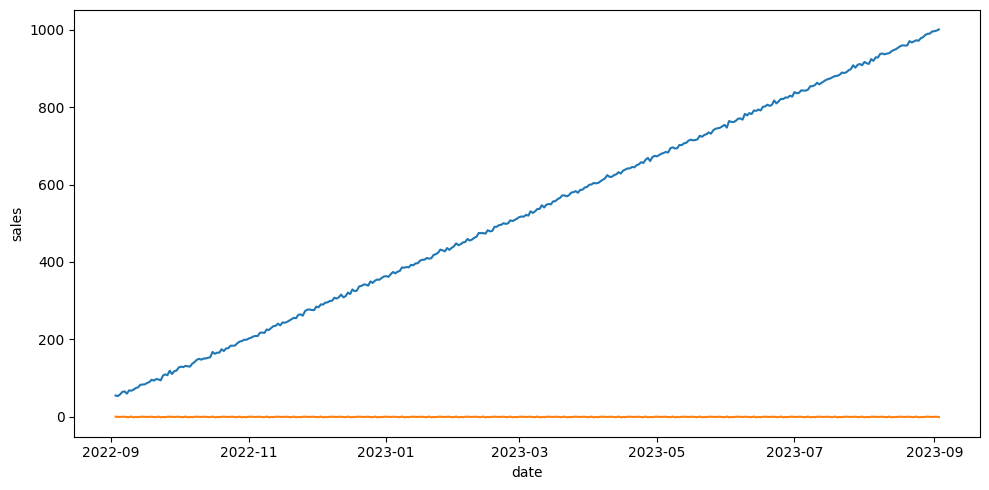

In [18]:
seasonal = decomposition.seasonal
fig, axis = plt.subplots(figsize = (10, 5))
sns.lineplot(data = df['sales'])
sns.lineplot(data = seasonal)
plt.tight_layout()
plt.show()

In [19]:
def test_stationarity(timeseries):
    print("Resultados de la prueba de Dickey-Fuller:")
    dftest = adfuller(timeseries, autolag = "AIC")
    dfoutput = pd.Series(dftest[0:4], index = ["Test Statistic", "p-value", "#Lags Used", "Number of Observations Used"])
    for key,value in dftest[4].items():
        dfoutput["Critical Value (%s)"%key] = value
    return dfoutput

test_stationarity(df['sales'])

Resultados de la prueba de Dickey-Fuller:


Test Statistic                   0.545414
p-value                          0.986190
#Lags Used                      13.000000
Number of Observations Used    352.000000
Critical Value (1%)             -3.449065
Critical Value (5%)             -2.869786
Critical Value (10%)            -2.571163
dtype: float64

#### El p-value es mayor a 0.05, esto significa que nuestra hipótesis nula será rechazada y tomaremos esta serie como no estacionaria

### Variabilidad

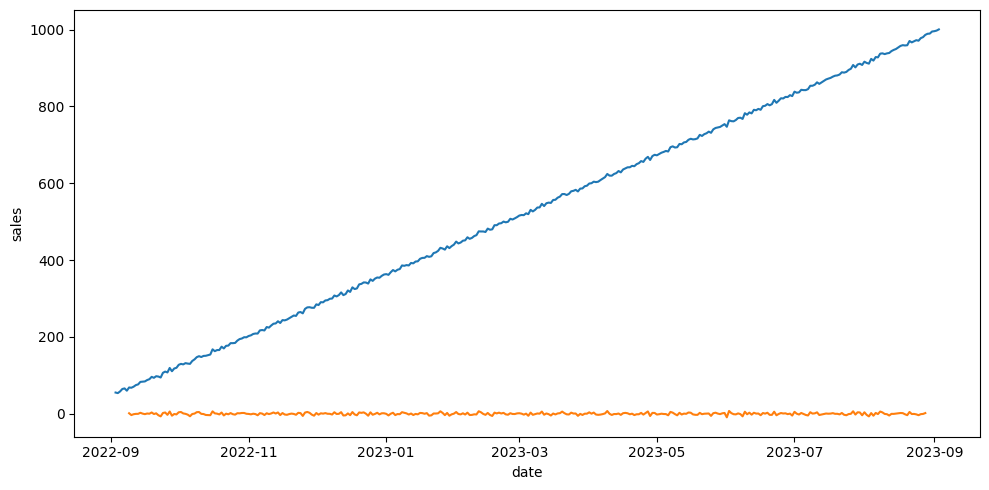

In [20]:
residual = decomposition.resid
fig, axis = plt.subplots(figsize = (10, 5))
sns.lineplot(data = df['sales'])
sns.lineplot(data = residual)
plt.tight_layout()
plt.show()

### Autocorrelación

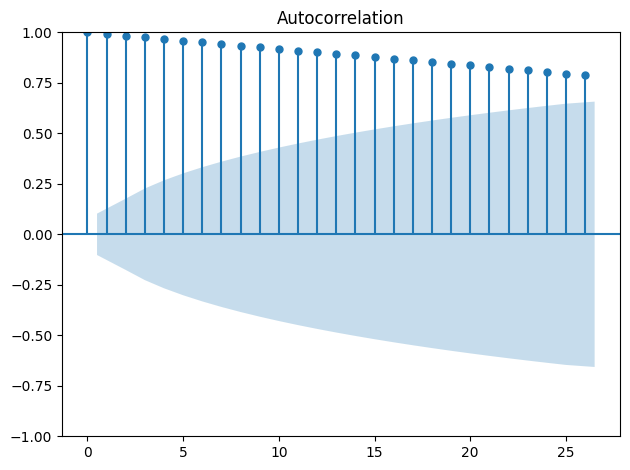

In [21]:
plot_acf(df['sales'])
plt.tight_layout()
plt.show()

## Entrenamiento del modelo

#### Debemos transformar la serie en estacionaria para poder trabajar con el modelo `auto_arima`

In [22]:
df_stationary = df['sales'].diff().dropna()

test_stationarity(df_stationary)

Resultados de la prueba de Dickey-Fuller:


Test Statistic                -9.430263e+00
p-value                        5.212954e-16
#Lags Used                     1.200000e+01
Number of Observations Used    3.520000e+02
Critical Value (1%)           -3.449065e+00
Critical Value (5%)           -2.869786e+00
Critical Value (10%)          -2.571163e+00
dtype: float64

In [28]:
df_stationary

date
2022-09-04   -1.488946
2022-09-05    4.338482
2022-09-06    6.389205
2022-09-07    1.482734
2022-09-08   -5.931768
                ...   
2023-08-30    0.518681
2023-08-31    5.386972
2023-09-01    0.827090
2023-09-02    1.535798
2023-09-03    3.132571
Name: sales, Length: 365, dtype: float64

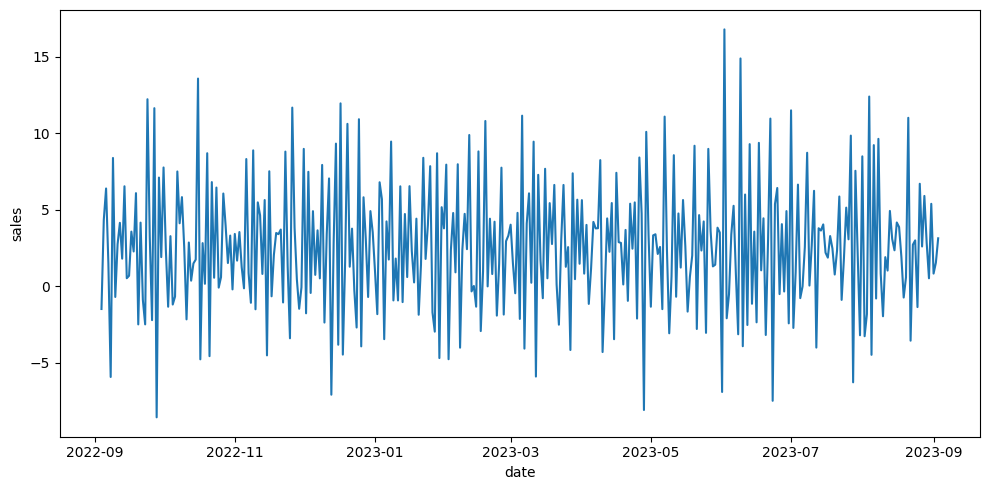

In [23]:
fig, axis = plt.subplots(figsize = (10, 5))
sns.lineplot(data = df_stationary)
plt.tight_layout()
plt.show()

#### Generamos y entrenamos el modelo

In [24]:
model_arima = auto_arima(df_stationary, seasonal = True, trace = True, m = 12)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=1847.124, Time=3.42 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=2096.542, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=1972.854, Time=0.38 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=inf, Time=2.11 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=2209.657, Time=0.04 sec
 ARIMA(2,0,2)(0,0,1)[12] intercept   : AIC=1845.127, Time=2.71 sec
 ARIMA(2,0,2)(0,0,0)[12] intercept   : AIC=1843.049, Time=1.12 sec
 ARIMA(2,0,2)(1,0,0)[12] intercept   : AIC=1845.092, Time=2.58 sec
 ARIMA(1,0,2)(0,0,0)[12] intercept   : AIC=1843.587, Time=0.34 sec
 ARIMA(2,0,1)(0,0,0)[12] intercept   : AIC=1841.533, Time=1.00 sec
 ARIMA(2,0,1)(1,0,0)[12] intercept   : AIC=1843.436, Time=2.88 sec
 ARIMA(2,0,1)(0,0,1)[12] intercept   : AIC=1843.433, Time=3.16 sec
 ARIMA(2,0,1)(1,0,1)[12] intercept   : AIC=inf, Time=3.39 sec
 ARIMA(1,0,1)(0,0,0)[12] intercept   : AIC=1839.553, Time=0.36 sec
 ARIMA(1,0,1)(1,0,0)[12] inte

In [25]:
model_arima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  365
Model:               SARIMAX(1, 0, 1)   Log Likelihood                -915.776
Date:                Mon, 21 Jul 2025   AIC                           1839.553
Time:                        17:07:46   BIC                           1855.152
Sample:                    09-04-2022   HQIC                          1845.752
                         - 09-03-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      2.8110      0.134     21.055      0.000       2.549       3.073
ar.L1         -0.0821      0.052     -1.592      0.111      -0.183       0.019
ma.L1         -0.9413      0.020    -47.701      0.000      -0.980      -0.903
sigma2         8.7903      0.688     12.777      0.000       7.442      10.139
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 0.76
Prob(Q):                              1.00   Prob(JB):                         0.68
Heteroskedasticity (H):               0.90   Skew:                             0.07
Prob(H) (two-sided):                  0.58   Kurtosis:                         2.82
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Predicción del modelo

In [29]:
forecast = model_arima.predict(200)
forecast

2023-09-04    1.675366
2023-09-05    2.673520
2023-09-06    2.591621
2023-09-07    2.598341
2023-09-08    2.597789
                ...   
2024-03-17    2.597831
2024-03-18    2.597831
2024-03-19    2.597831
2024-03-20    2.597831
2024-03-21    2.597831
Freq: D, Length: 200, dtype: float64

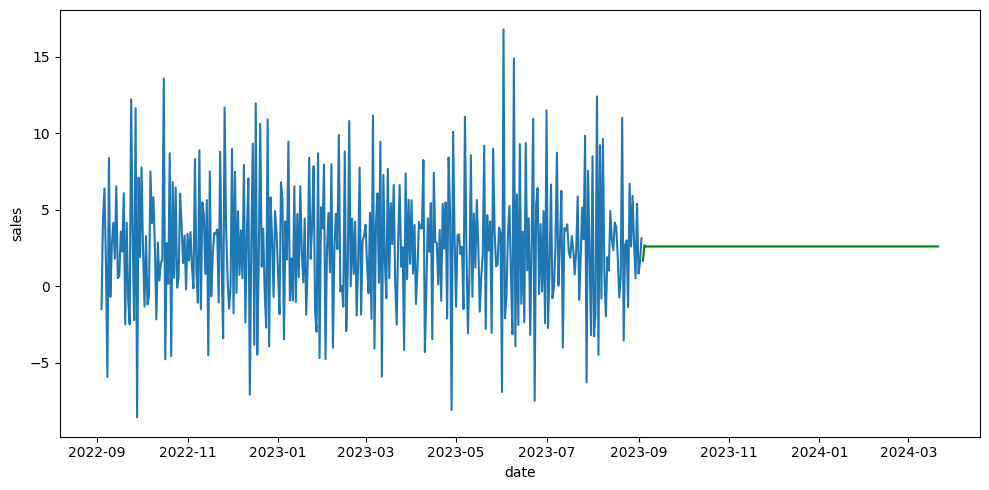

In [30]:
fig, axis = plt.subplots(figsize = (10, 5))
sns.lineplot(data = df_stationary)
sns.lineplot(data = forecast, c = "green")
plt.tight_layout()
plt.show()